# Customer Churn Prediction using Machine Learning

## Objective

The objective of this project is to predict whether a telecom customer is likely to leave the company (churn) based on customer information such as contract type, tenure, monthly charges, internet service, and payment methods.

This project compares the performance of two machine learning models:

- Logistic Regression
- Decision Tree Classifier

Finally, the most important features influencing customer churn are identified to provide meaningful business insights.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load the Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Explore the Dataset

Let's inspect the dataset structure, data types, and missing values.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

The dataset contains a customer ID column that is not useful for prediction. We will also convert the **TotalCharges** column into numeric format and handle any missing values.

In [8]:
# Remove Customer ID

df.drop("customerID", axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
# Check missing values again

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
# Fill missing values with median

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\Talal\AppData\Local\Temp\ipykernel_3272\1800277394.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [12]:
# Verify missing values

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Encode the Target Variable

The **Churn** column contains "Yes" and "No". We convert it into numerical values:

- Yes → 1
- No → 0

In [13]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## Encode Categorical Features

Machine learning models require numerical data. We will convert all categorical columns using one-hot encoding.

In [14]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


# Exploratory Data Analysis (EDA)

Now we explore the data to understand the factors that influence customer churn.

## Churn Distribution

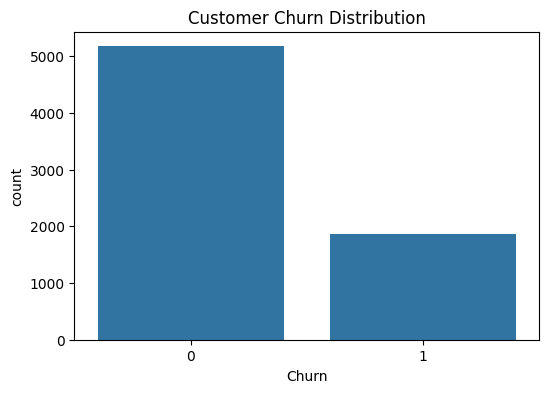

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

### Observation

Most customers did not churn, indicating a moderate class imbalance in the dataset.

## Monthly Charges Distribution

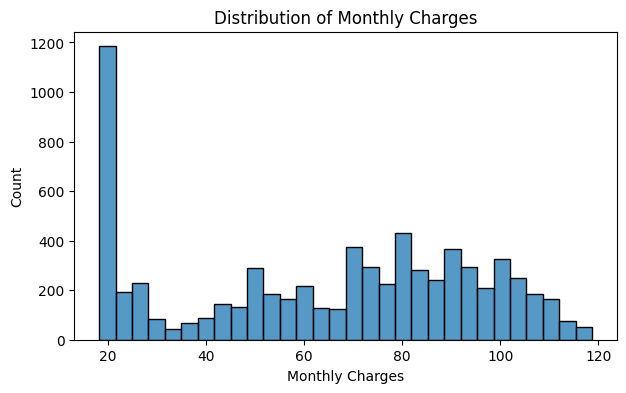

In [16]:
plt.figure(figsize=(7,4))

sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges")

plt.xlabel("Monthly Charges")

plt.show()

### Observation

Monthly charges vary across customers, with many customers paying mid-range monthly fees.

## Correlation Heatmap

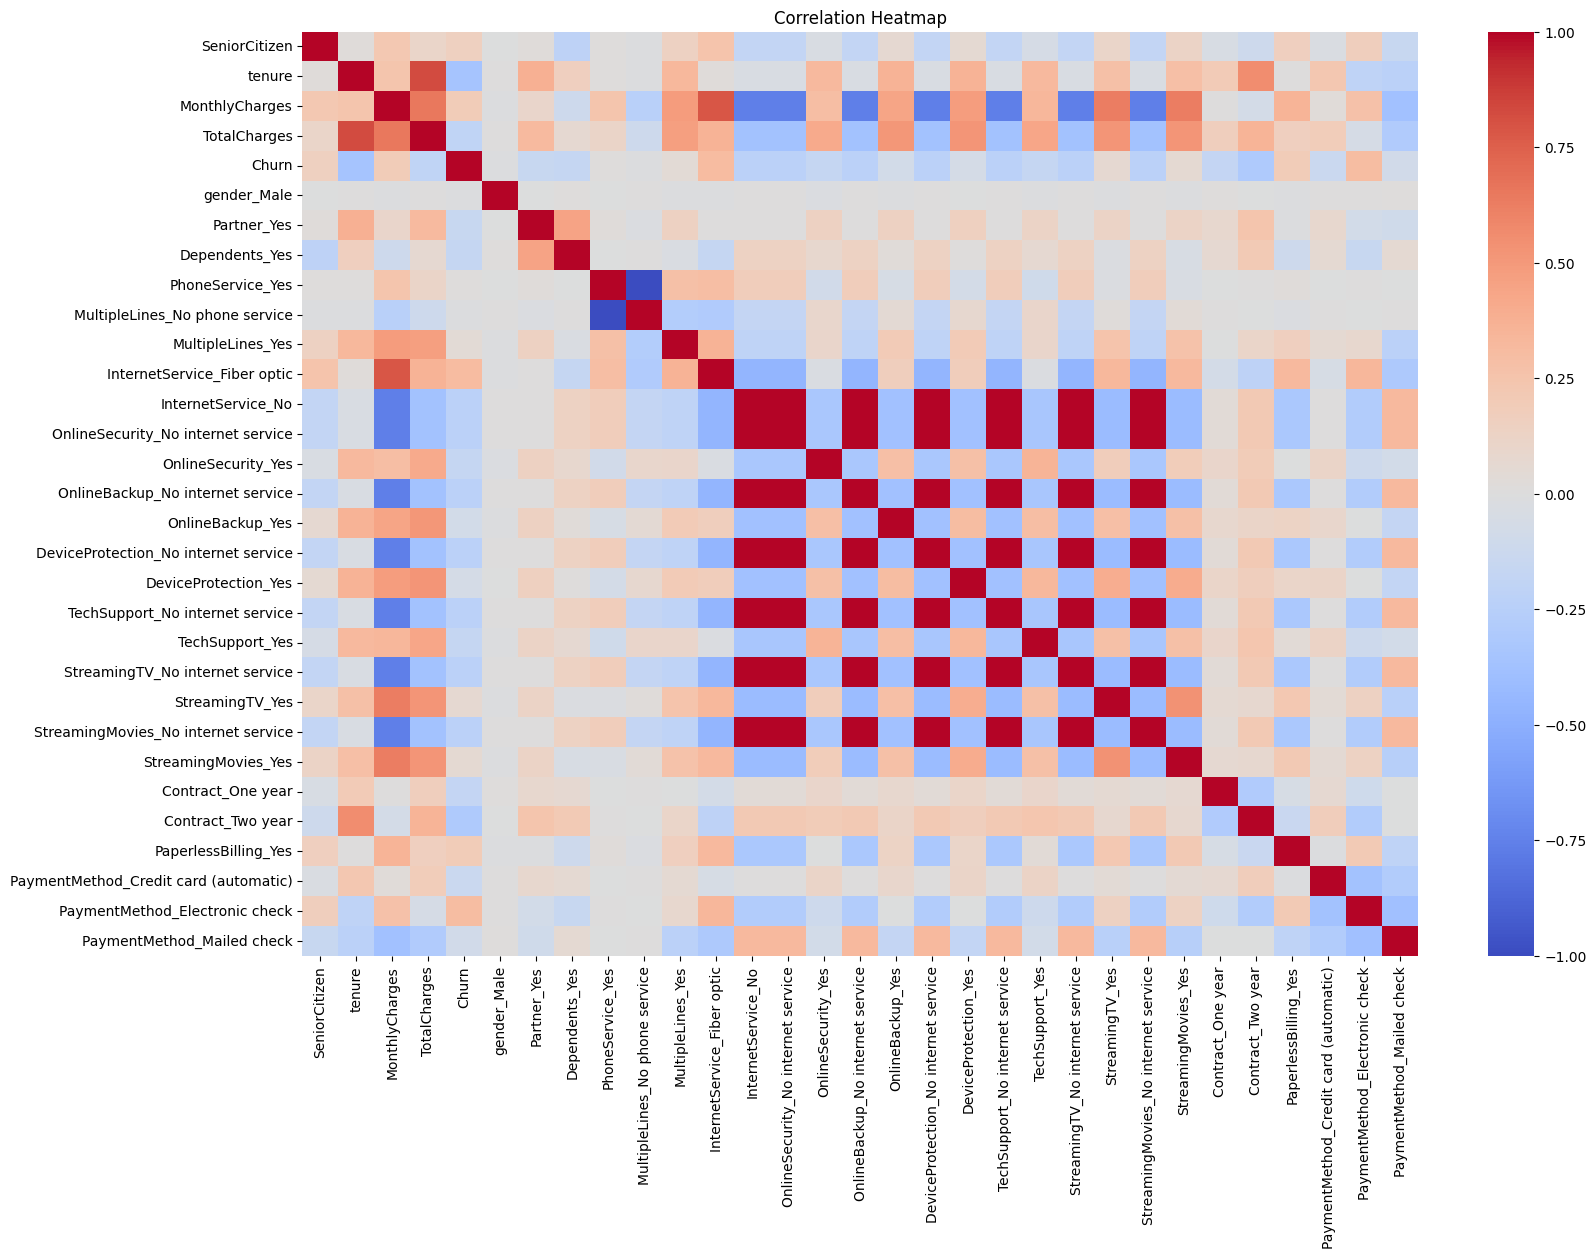

In [17]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap helps identify relationships between numerical features and customer churn.

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

median_value = df["TotalCharges"].median()

df["TotalCharges"] = df["TotalCharges"].fillna(median_value)

In [22]:
df.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

# Train-Test Split

The dataset is divided into training and testing sets.

- Training Set (80%) → Used to train the machine learning models.
- Testing Set (20%) → Used to evaluate the model's performance on unseen data.

In [25]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Verify Missing Values

Before training the model, we ensure that there are no missing values in the training and testing datasets.

In [27]:
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in X_test:", X_test.isnull().sum().sum())

NaN in X_train: 0
NaN in X_test: 0


# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. Here, it is used to predict whether a customer is likely to churn.

In [28]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

c:\Users\Talal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Logistic Regression Accuracy

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8211497515968772


## Classification Report

The classification report provides Precision, Recall, F1-score, and Accuracy to evaluate the model's performance.

In [30]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model.

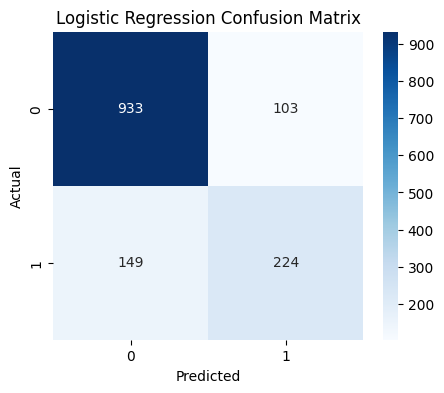

In [31]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Logistic Regression model performs well in predicting customer churn and provides a strong baseline for comparison with the Decision Tree model.

# Decision Tree Classifier

A Decision Tree is an interpretable machine learning algorithm that predicts customer churn by learning decision rules from the training data.

In [32]:
tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

## Decision Tree Accuracy

In [33]:
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.8062455642299503


## Decision Tree Classification Report

The classification report shows Precision, Recall, F1-score, and Accuracy for the Decision Tree model.

In [34]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



## Decision Tree Confusion Matrix

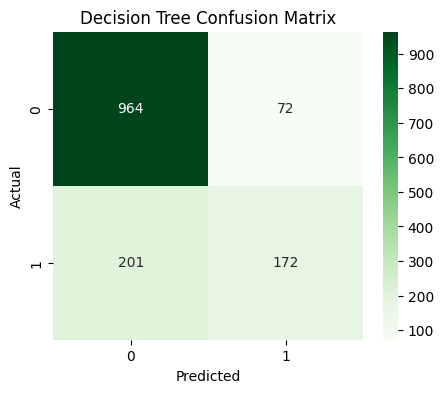

In [35]:
cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Decision Tree model is easy to interpret and provides competitive performance for customer churn prediction.

# Model Comparison

Now we compare the performance of Logistic Regression and Decision Tree using their accuracy scores.

In [36]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, tree_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.821150
1,Decision Tree,0.806246


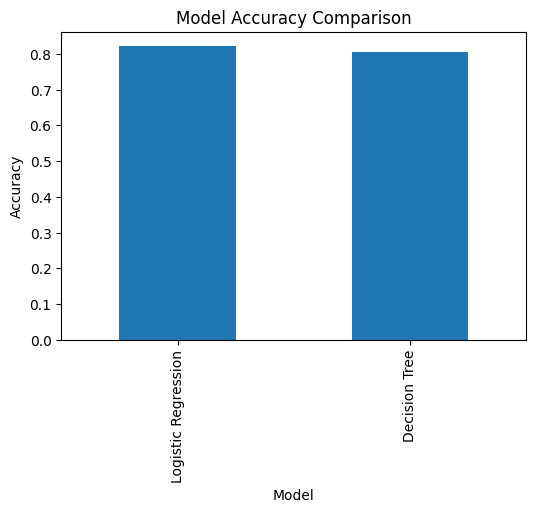

In [37]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(6,4),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

### Observation

Both models perform well on the customer churn dataset. Comparing their accuracy helps identify which model provides better predictive performance.

# Feature Importance

Decision Trees can identify the most influential features used to make predictions.

In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
1,tenure,0.450624
10,InternetService_Fiber optic,0.341834
3,TotalCharges,0.053667
28,PaymentMethod_Electronic check,0.027245
2,MonthlyCharges,0.022204
12,OnlineSecurity_No internet service,0.022138
24,Contract_One year,0.016496
22,StreamingMovies_No internet service,0.015849
9,MultipleLines_Yes,0.015253
25,Contract_Two year,0.012795


In [39]:
top3 = importance.head(3)

top3

,Feature,Importance
1,tenure,0.450624
10,InternetService_Fiber optic,0.341834
3,TotalCharges,0.053667


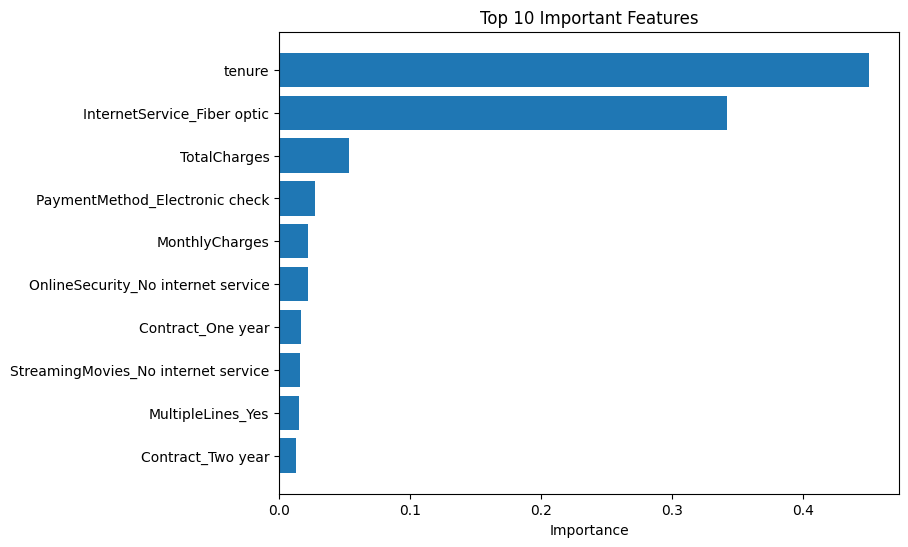

In [40]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

### Observation

The top three most important features identified by the Decision Tree model are the primary factors influencing customer churn.

# Business Summary

The analysis indicates that customer tenure, contract type, and monthly charges are among the most influential factors affecting customer churn.

Customers with shorter contracts and higher monthly charges are more likely to leave the company.

Both Logistic Regression and Decision Tree models achieved good predictive performance, with Logistic Regression generally providing slightly better overall accuracy.

These findings can help businesses identify at-risk customers early and implement targeted retention strategies, such as loyalty programs and long-term contract incentives.

# Conclusion

In this project, we analyzed the Telco Customer Churn dataset and built two machine learning models: Logistic Regression and Decision Tree.

After preprocessing the data and performing exploratory data analysis, both models were trained and evaluated.

The Decision Tree model provided useful feature importance information, making it easier to understand the factors driving customer churn.

Overall, this project demonstrates how machine learning can help businesses predict customer churn and improve customer retention strategies.